# Baseline EDA рекомендательной системы

Этот notebook фиксирует текущее состояние baseline-рекомендателя на синтетических данных. Он вдохновлён `recommendations_eda.ipynb`, но убирает лишнее и добавляет метрики, которые потом удобно сравнивать с:

- вариантом с полноценным Gale-Shapley matching;
- вариантом, где решения `APPROVED/REJECTED` принимаются по project-side ranking;
- будущими версиями весов или сигналов рекомендателя.

Важно: текущие статусы заявок в демо-данных синтетические и задаются случайно с весами, поэтому они не являются настоящим ground truth качества отбора.

## План анализа

1. Подключаемся к Django-БД и фиксируем локальную модель embeddings.
2. Проверяем объём данных: проекты, студенты, заявки, статусы.
3. Смотрим распределения проектов, студентов и заявок.
4. Оцениваем активность четырёх сигналов рекомендателя.
5. Считаем baseline recommendation quality на синтетических заявках: hit-rate@K и rank заявленных проектов.
6. Делаем ablation через Spearman correlation: насколько меняется ранжирование при выключении каждого сигнала.
7. Фиксируем baseline outcome по текущим случайным статусам заявок: заполненность, approvals, capacity pressure.
8. Оставляем TODO-места для будущего сравнения с Gale-Shapley и project-side ranking.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'generate_data':
    ROOT = ROOT.parent
SRC = ROOT / 'src'
MODEL_PATH = ROOT / 'models' / 'paraphrase-multilingual-MiniLM-L12-v2'

sys.path.insert(0, str(SRC))
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'config.settings')
os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')

# Notebook запускается с хоста Windows, поэтому подключаемся к опубликованному порту Docker,
# а не к docker-compose hostname `db`, который виден только контейнерам.
os.environ['POSTGRES_HOST'] = 'localhost'
os.environ['POSTGRES_PORT'] = '5433'
os.environ['PYTHONIOENCODING'] = 'utf-8'
os.environ['PYTHONUTF8'] = '1'

print('ROOT:', ROOT)
print('SRC:', SRC)
print('MODEL_PATH exists:', MODEL_PATH.exists())
print('POSTGRES:', os.environ['POSTGRES_HOST'], os.environ['POSTGRES_PORT'])

ROOT: C:\Users\apecx\anaconda_projects\2025_hse_dsa
SRC: C:\Users\apecx\anaconda_projects\2025_hse_dsa\src
MODEL_PATH exists: True
POSTGRES: localhost 5433


In [2]:
import django

django.setup()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from django.contrib.auth import get_user_model
from django.db.models import Count

from apps.projects.models import Application, Project, Tag
from apps.projects import embeddings as E
from apps.projects.services import (
    TAG_WEIGHT,
    COLLAB_WEIGHT,
    SEMANTIC_WEIGHT,
    GRADES_WEIGHT,
    _collaborative_scores,
    _grades_scores,
    _semantic_scores,
    _tag_scores,
    get_recommended_projects,
)

if MODEL_PATH.exists():
    E.MODEL_NAME = str(MODEL_PATH)
    E._model.cache_clear()

User = get_user_model()
plt.style.use('default')
pd.set_option('display.max_colwidth', 120)

print('Recommendation weights:', {
    'tag': TAG_WEIGHT,
    'collab': COLLAB_WEIGHT,
    'semantic': SEMANTIC_WEIGHT,
    'grades': GRADES_WEIGHT,
})
print('Embedding model:', E.MODEL_NAME)

Recommendation weights: {'tag': 0.45, 'collab': 0.25, 'semantic': 0.2, 'grades': 0.1}
Embedding model: C:\Users\apecx\anaconda_projects\2025_hse_dsa\models\paraphrase-multilingual-MiniLM-L12-v2


,metric,value
0,projects,200
1,students,150
2,applications,295
3,tags,20
4,projects_with_embeddings,200
5,students_with_embeddings,150


,status,n
0,APPROVED,160
1,PENDING,93
2,REJECTED,42


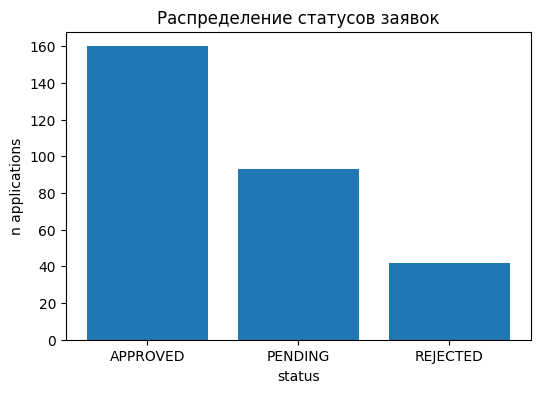

In [3]:
projects = list(Project.objects.prefetch_related('tags', 'participants').order_by('id'))
students = list(User.objects.filter(role=User.Role.STUDENT).prefetch_related('interests').order_by('id'))
applications = list(
    Application.objects.select_related('student', 'project', 'project__creator')
    .prefetch_related('project__tags')
    .order_by('id')
)

summary = pd.DataFrame([
    {'metric': 'projects', 'value': len(projects)},
    {'metric': 'students', 'value': len(students)},
    {'metric': 'applications', 'value': len(applications)},
    {'metric': 'tags', 'value': Tag.objects.count()},
    {'metric': 'projects_with_embeddings', 'value': sum(bool(p.embedding) for p in projects)},
    {'metric': 'students_with_embeddings', 'value': sum(bool(u.profile_embedding) for u in students)},
])
display(summary)

status_df = pd.DataFrame(list(Application.objects.values('status').annotate(n=Count('id')).order_by('status')))
display(status_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(status_df['status'], status_df['n'])
ax.set_title('Распределение статусов заявок')
ax.set_xlabel('status')
ax.set_ylabel('n applications')
plt.show()

,n_tags,title_len,desc_len,capacity,participants,applications
count,200.000000,200.000000,200.000000,200.0,200.000000,200.000000
mean,3.505000,80.700000,247.210000,3.0,0.800000,1.475000
std,0.601485,30.062581,51.587033,0.0,1.307112,2.140628
min,2.000000,17.000000,152.000000,3.0,0.000000,0.000000
25%,3.000000,60.000000,197.000000,3.0,0.000000,0.000000
50%,4.000000,77.000000,250.500000,3.0,0.000000,1.000000
75%,4.000000,97.250000,296.000000,3.0,1.000000,2.000000
max,5.000000,176.000000,347.000000,3.0,8.000000,11.000000


,project_id,title,creator,capacity,participants,applications
172,173,Платформа для аналитики финансовых результатов компаний,teacher_5,3,8,11
182,183,Система контроля качества для e-commerce на основе кросс-доменной адаптации методов обнаружения фейков с использован...,teacher_123,3,5,10
185,186,Разработка стратегии выхода 5Post на рынок экспресс-доставки в РФ на основе конкурентного и рыночного анализа,teacher_125,3,7,10
61,62,Разработка прототипа 2D игры платформера,teacher_51,3,5,9
179,180,Разработка интеллектуальной системы управления игровым процессом и достижениями в Steam,teacher_18,3,6,8
156,157,Разработка и анализ новых инструментов промпт-инжиниринга с использованием методов Design-мышления,teacher_44,3,3,7
101,102,Разработка социальной сети с рекомендательной системой постов на основе методов машинного обучения,teacher_7,3,2,6
188,189,Разработка телеграмм бота для фитнеса (от партнеров Т- банк),teacher_18,3,2,6
132,133,Маркетинговая стратегия компании,teacher_95,3,4,6
180,181,Взаимосвязь практик эмоционального потребления и финансового поведения студенческой молодежи московских вузов,teacher_121,3,2,6


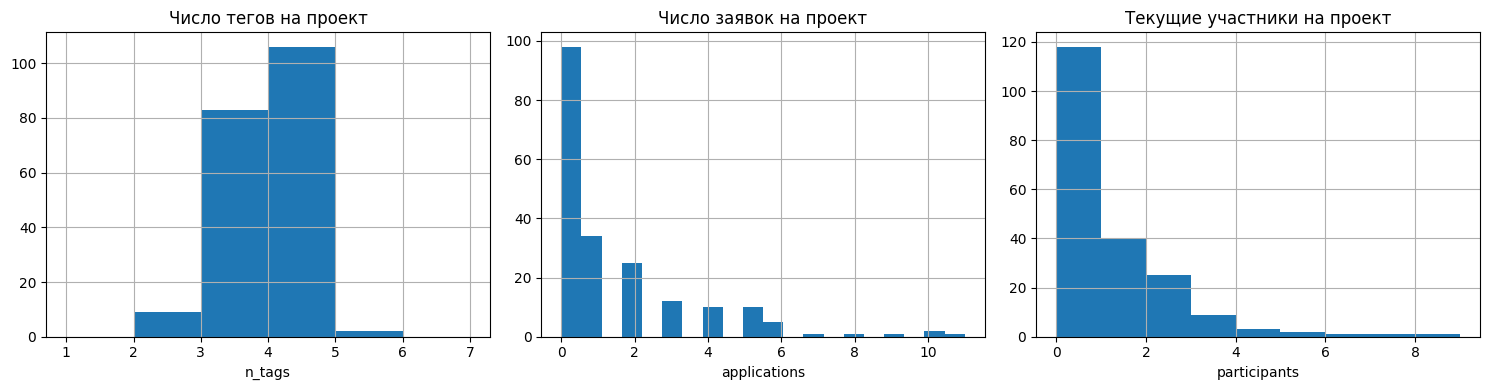

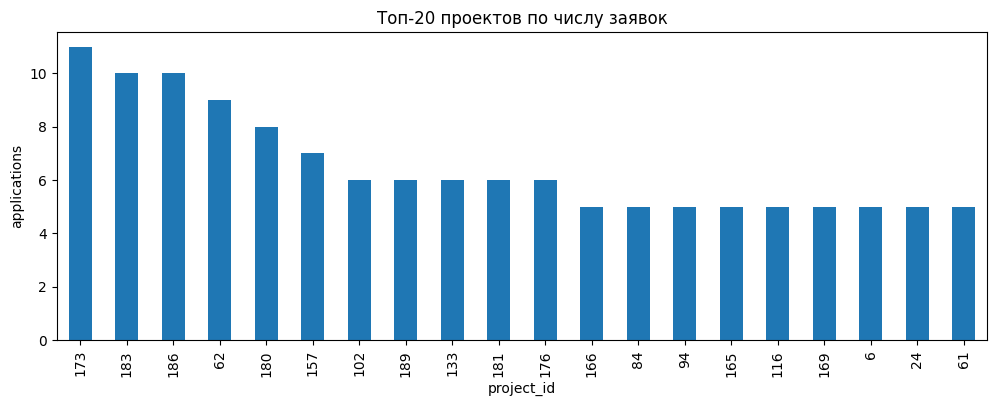

In [4]:
project_rows = []
for p in projects:
    n_apps = sum(1 for a in applications if a.project_id == p.id)
    project_rows.append({
        'project_id': p.id,
        'title': p.title,
        'creator': p.creator.username,
        'status': p.status,
        'n_tags': p.tags.count(),
        'title_len': len(p.title or ''),
        'desc_len': len(p.description or ''),
        'capacity': p.max_participants,
        'participants': p.participants.count(),
        'applications': n_apps,
        'has_embedding': bool(p.embedding),
    })

project_df = pd.DataFrame(project_rows)
display(project_df[['n_tags', 'title_len', 'desc_len', 'capacity', 'participants', 'applications']].describe())
display(project_df.sort_values('applications', ascending=False).head(10)[['project_id', 'title', 'creator', 'capacity', 'participants', 'applications']])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
project_df['n_tags'].hist(ax=axes[0], bins=range(1, 8))
axes[0].set_title('Число тегов на проект')
axes[0].set_xlabel('n_tags')

project_df['applications'].hist(ax=axes[1], bins=20)
axes[1].set_title('Число заявок на проект')
axes[1].set_xlabel('applications')

project_df['participants'].hist(ax=axes[2], bins=range(0, int(project_df['participants'].max()) + 2))
axes[2].set_title('Текущие участники на проект')
axes[2].set_xlabel('participants')
plt.tight_layout()
plt.show()

project_df.sort_values('applications', ascending=False).head(20).plot(
    x='project_id', y='applications', kind='bar', legend=False, figsize=(12, 4)
)
plt.title('Топ-20 проектов по числу заявок')
plt.ylabel('applications')
plt.show()

,n_interests,bio_len,cover_len,n_grades,n_grade_profile,applications,approved,pending,rejected
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.00000,150.000000
mean,2.993333,245.373333,384.893333,2.993333,2.993333,1.966667,1.066667,0.62000,0.280000
std,0.863088,41.747812,62.829389,0.863088,0.863088,0.797788,0.808235,0.68218,0.544897
min,2.000000,181.000000,275.000000,2.000000,2.000000,1.000000,0.000000,0.00000,0.000000
25%,2.000000,209.000000,333.000000,2.000000,2.000000,1.000000,0.000000,0.00000,0.000000
50%,3.000000,234.000000,351.500000,3.000000,3.000000,2.000000,1.000000,1.00000,0.000000
75%,4.000000,282.000000,440.000000,4.000000,4.000000,3.000000,2.000000,1.00000,0.000000
max,4.000000,351.000000,522.000000,4.000000,4.000000,3.000000,3.000000,2.00000,2.000000


,student_id,username,program,campus,study_year,degree_level,n_interests,bio_len,cover_len,n_grades,n_grade_profile,applications,approved,pending,rejected,has_embedding
0,131,synthetic_student_1,Прикладная математика и информатика,Москва,1,BACHELOR,4,320,424,4,4,1,1,0,0,True
1,132,synthetic_student_2,Прикладная математика и информатика,Москва,2,BACHELOR,2,300,457,2,2,3,0,2,1,True
2,133,synthetic_student_3,Прикладная математика и информатика,Нижний Новгород,4,BACHELOR,2,318,437,2,2,3,3,0,0,True
3,134,synthetic_student_4,Бизнес-информатика,Москва,2,BACHELOR,2,297,428,2,2,1,0,1,0,True
4,135,synthetic_student_5,Бизнес-информатика,Москва,4,BACHELOR,3,311,424,3,3,2,2,0,0,True
5,136,synthetic_student_6,Прикладная математика и информатика,Москва,3,BACHELOR,2,326,455,2,2,1,1,0,0,True
6,137,synthetic_student_7,Анализ данных в экономике,Москва,1,MASTER,3,304,466,3,3,3,1,2,0,True
7,138,synthetic_student_8,Анализ данных в экономике,Нижний Новгород,1,MASTER,2,309,403,2,2,3,2,1,0,True
8,139,synthetic_student_9,Анализ данных в экономике,Санкт-Петербург,1,MASTER,4,308,436,4,4,3,0,2,1,True
9,140,synthetic_student_10,Бизнес-информатика,Нижний Новгород,4,BACHELOR,2,351,474,2,2,1,1,0,0,True


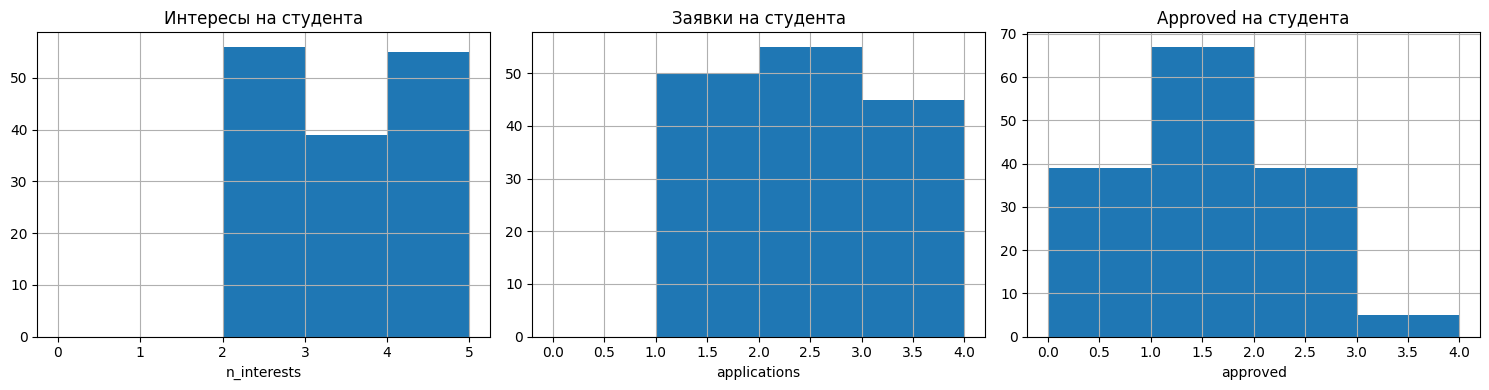

In [5]:
student_rows = []
for u in students:
    user_apps = [a for a in applications if a.student_id == u.id]
    student_rows.append({
        'student_id': u.id,
        'username': u.username,
        'program': u.program,
        'campus': u.campus,
        'study_year': u.study_year,
        'degree_level': u.degree_level,
        'n_interests': u.interests.count(),
        'bio_len': len(u.bio or ''),
        'cover_len': len(u.cover_letter or ''),
        'n_grades': len(u.grades_json or {}) if isinstance(u.grades_json, dict) else 0,
        'n_grade_profile': len(u.grade_profile or {}) if isinstance(u.grade_profile, dict) else 0,
        'applications': len(user_apps),
        'approved': sum(a.status == Application.Status.APPROVED for a in user_apps),
        'pending': sum(a.status == Application.Status.PENDING for a in user_apps),
        'rejected': sum(a.status == Application.Status.REJECTED for a in user_apps),
        'has_embedding': bool(u.profile_embedding),
    })

student_df = pd.DataFrame(student_rows)
display(student_df[['n_interests', 'bio_len', 'cover_len', 'n_grades', 'n_grade_profile', 'applications', 'approved', 'pending', 'rejected']].describe())
display(student_df.head(10))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
student_df['n_interests'].hist(ax=axes[0], bins=range(0, int(student_df['n_interests'].max()) + 2))
axes[0].set_title('Интересы на студента')
axes[0].set_xlabel('n_interests')

student_df['applications'].hist(ax=axes[1], bins=range(0, int(student_df['applications'].max()) + 2))
axes[1].set_title('Заявки на студента')
axes[1].set_xlabel('applications')

student_df['approved'].hist(ax=axes[2], bins=range(0, int(student_df['approved'].max()) + 2))
axes[2].set_title('Approved на студента')
axes[2].set_xlabel('approved')
plt.tight_layout()
plt.show()

,signal,students_active,mean_positive_projects
0,tag,150,79.193333
1,collab,150,33.826667
2,semantic,150,198.840000
3,grades,150,79.193333


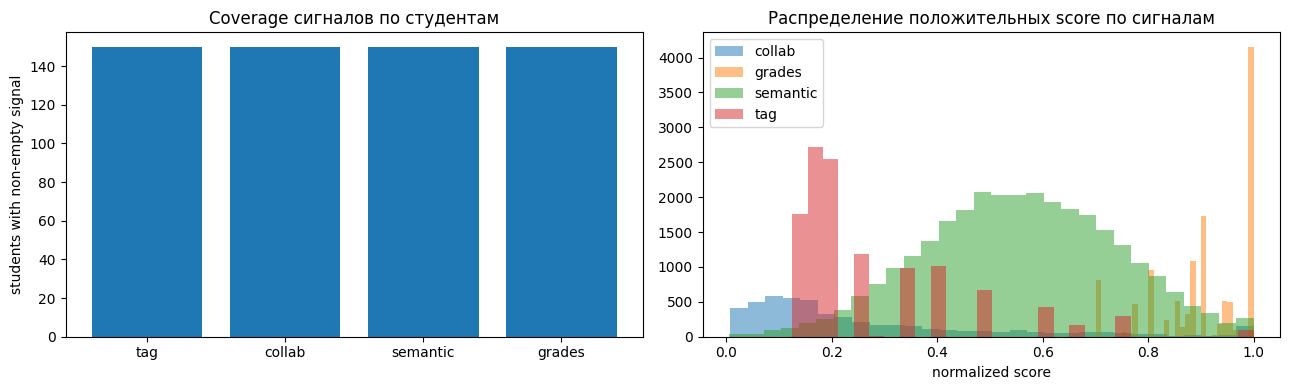

In [6]:
def candidate_projects_for_eda(user):
    return [
        p for p in projects
        if p.status == Project.Status.RECRUITMENT
        and p.creator_id != user.id
        and not p.participants.filter(pk=user.id).exists()
    ]


def raw_signal_vectors(user, cand):
    return {
        'tag': _tag_scores(user, cand),
        'collab': _collaborative_scores(user, cand),
        'semantic': _semantic_scores(user, cand),
        'grades': _grades_scores(user, cand),
    }

coverage_rows = []
signal_values = []
for u in students:
    cand = candidate_projects_for_eda(u)
    signals = raw_signal_vectors(u, cand)
    row = {'student_id': u.id, 'username': u.username, 'n_candidates': len(cand)}
    for name, scores in signals.items():
        row[f'{name}_active'] = bool(scores)
        row[f'{name}_n_positive'] = len(scores)
        for score in scores.values():
            signal_values.append({'signal': name, 'score': score})
    coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows)
signal_values_df = pd.DataFrame(signal_values)

coverage_summary = pd.DataFrame([
    {
        'signal': name,
        'students_active': int(coverage_df[f'{name}_active'].sum()),
        'mean_positive_projects': float(coverage_df[f'{name}_n_positive'].mean()),
    }
    for name in ['tag', 'collab', 'semantic', 'grades']
])
display(coverage_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(coverage_summary['signal'], coverage_summary['students_active'])
axes[0].set_title('Coverage сигналов по студентам')
axes[0].set_ylabel('students with non-empty signal')

for signal_name, group in signal_values_df.groupby('signal'):
    axes[1].hist(group['score'], bins=30, alpha=0.5, label=signal_name)
axes[1].set_title('Распределение положительных score по сигналам')
axes[1].set_xlabel('normalized score')
axes[1].legend()
plt.tight_layout()
plt.show()

processed students: 25/150
processed students: 50/150
processed students: 75/150
processed students: 100/150
processed students: 125/150
processed students: 150/150


,metric,value
0,applications_total,295.000000
1,share_in_recommendations,0.457627
2,hit@1,0.027119
3,hit@3,0.111864
4,hit@5,0.186441
5,hit@10,0.237288
6,hit@20,0.335593
7,median_rank_if_found,9.000000


,student_id,username,project_id,rank,in_recommendations,hit_at_1,hit_at_3,hit_at_5,hit_at_10,hit_at_20
51,157,synthetic_student_27,36,1.0,True,True,True,True,True,True
127,195,synthetic_student_65,36,1.0,True,True,True,True,True,True
105,186,synthetic_student_56,169,1.0,True,True,True,True,True,True
87,177,synthetic_student_47,36,1.0,True,True,True,True,True,True
238,254,synthetic_student_124,36,1.0,True,True,True,True,True,True
179,223,synthetic_student_93,138,1.0,True,True,True,True,True,True
159,212,synthetic_student_82,169,1.0,True,True,True,True,True,True
152,207,synthetic_student_77,166,1.0,True,True,True,True,True,True
78,172,synthetic_student_42,181,2.0,True,False,True,True,True,True
76,171,synthetic_student_41,188,2.0,True,False,True,True,True,True


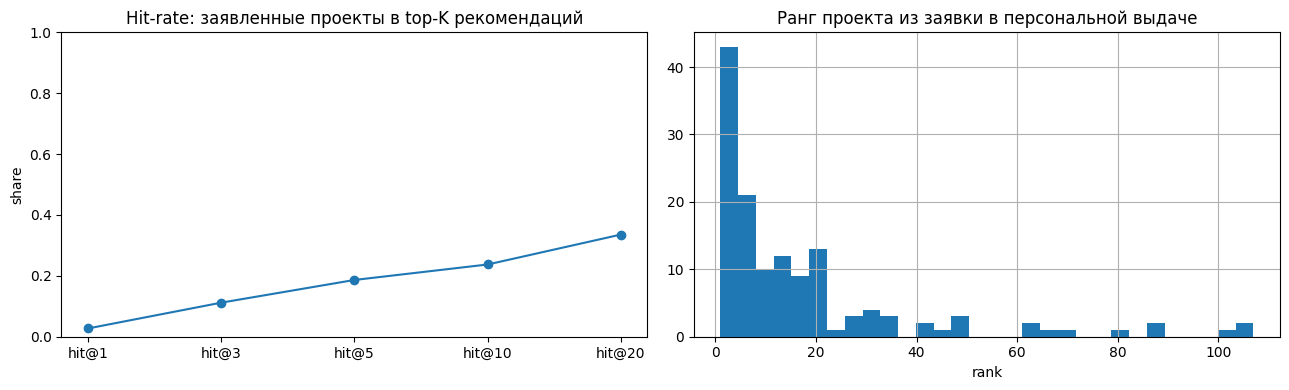

In [10]:
def rank_from_cached_signals(cand, signals, weights):
    tag_w, collab_w, semantic_w, grades_w = weights
    weighted_scores = {}
    for p in cand:
        score = (
            tag_w * signals['tag'].get(p.id, 0.0)
            + collab_w * signals['collab'].get(p.id, 0.0)
            + semantic_w * signals['semantic'].get(p.id, 0.0)
            + grades_w * signals['grades'].get(p.id, 0.0)
        )
        if p.participants.count() >= p.max_participants:
            score *= 0.5
        weighted_scores[p.id] = score

    ranked = sorted(
        cand,
        key=lambda p: (-weighted_scores.get(p.id, 0.0), -p.created_at.timestamp()),
    )
    return [p.id for p in ranked if weighted_scores.get(p.id, 0.0) > 0], weighted_scores

# Кэш нужен, чтобы не пересчитывать semantic/collab/tag/grades в каждой следующей ячейке.
base_weights = (TAG_WEIGHT, COLLAB_WEIGHT, SEMANTIC_WEIGHT, GRADES_WEIGHT)
rank_cache = {}
for i, u in enumerate(students, start=1):
    cand = candidate_projects_for_eda(u)
    signals = raw_signal_vectors(u, cand)
    rec_ids, weighted_scores = rank_from_cached_signals(cand, signals, base_weights)
    rank_cache[u.id] = {
        'candidate_projects': cand,
        'signals': signals,
        'ranked_project_ids': rec_ids,
        'weighted_scores': weighted_scores,
    }
    if i % 25 == 0:
        print(f'processed students: {i}/{len(students)}')

rank_rows = []
for u in students:
    rec_ids = rank_cache[u.id]['ranked_project_ids']
    app_project_ids = [a.project_id for a in applications if a.student_id == u.id]
    for pid in app_project_ids:
        rank = rec_ids.index(pid) + 1 if pid in rec_ids else None
        rank_rows.append({
            'student_id': u.id,
            'username': u.username,
            'project_id': pid,
            'rank': rank,
            'in_recommendations': rank is not None,
            'hit_at_1': rank is not None and rank <= 1,
            'hit_at_3': rank is not None and rank <= 3,
            'hit_at_5': rank is not None and rank <= 5,
            'hit_at_10': rank is not None and rank <= 10,
            'hit_at_20': rank is not None and rank <= 20,
        })

rank_df = pd.DataFrame(rank_rows)
hit_summary = pd.DataFrame([
    {'metric': 'applications_total', 'value': len(rank_df)},
    {'metric': 'share_in_recommendations', 'value': rank_df['in_recommendations'].mean()},
    {'metric': 'hit@1', 'value': rank_df['hit_at_1'].mean()},
    {'metric': 'hit@3', 'value': rank_df['hit_at_3'].mean()},
    {'metric': 'hit@5', 'value': rank_df['hit_at_5'].mean()},
    {'metric': 'hit@10', 'value': rank_df['hit_at_10'].mean()},
    {'metric': 'hit@20', 'value': rank_df['hit_at_20'].mean()},
    {'metric': 'median_rank_if_found', 'value': rank_df.loc[rank_df['rank'].notna(), 'rank'].median()},
])
display(hit_summary)

display(rank_df.sort_values('rank', na_position='last').head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hits = hit_summary[hit_summary['metric'].isin(['hit@1', 'hit@3', 'hit@5', 'hit@10', 'hit@20'])]
axes[0].plot(hits['metric'], hits['value'], marker='o')
axes[0].set_ylim(0, 1)
axes[0].set_title('Hit-rate: заявленные проекты в top-K рекомендаций')
axes[0].set_ylabel('share')

rank_df.loc[rank_df['rank'].notna(), 'rank'].hist(ax=axes[1], bins=30)
axes[1].set_title('Ранг проекта из заявки в персональной выдаче')
axes[1].set_xlabel('rank')
plt.tight_layout()
plt.show()

,ablation,mean_spearman,median_spearman,min_spearman,students
2,no_semantic,0.827809,0.845349,0.455403,150
3,no_tag,0.956671,0.977407,0.731398,150
0,no_collab,0.984925,0.987889,0.898489,150
1,no_grades,0.991399,0.992717,0.963614,150


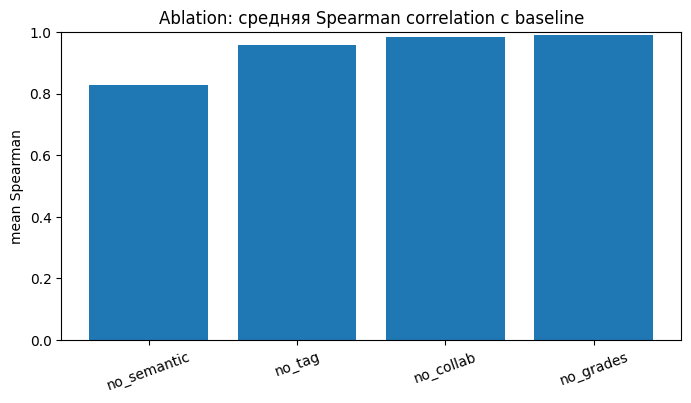

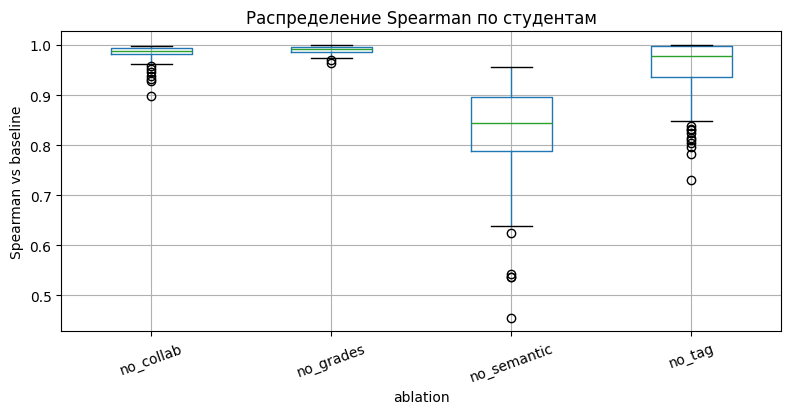

In [11]:
from scipy.stats import spearmanr

ablations = {
    'no_tag': (0.0, COLLAB_WEIGHT, SEMANTIC_WEIGHT, GRADES_WEIGHT),
    'no_collab': (TAG_WEIGHT, 0.0, SEMANTIC_WEIGHT, GRADES_WEIGHT),
    'no_semantic': (TAG_WEIGHT, COLLAB_WEIGHT, 0.0, GRADES_WEIGHT),
    'no_grades': (TAG_WEIGHT, COLLAB_WEIGHT, SEMANTIC_WEIGHT, 0.0),
}

ablation_rows = []
for name, weights in ablations.items():
    for u in students:
        cached = rank_cache[u.id]
        base_rank = cached['ranked_project_ids']
        alt_rank, _ = rank_from_cached_signals(
            cached['candidate_projects'],
            cached['signals'],
            weights,
        )
        common = [pid for pid in base_rank if pid in alt_rank]
        if len(common) < 3:
            continue
        base_positions = [base_rank.index(pid) for pid in common]
        alt_positions = [alt_rank.index(pid) for pid in common]
        corr = spearmanr(base_positions, alt_positions).correlation
        ablation_rows.append({
            'ablation': name,
            'student_id': u.id,
            'spearman_vs_base': corr,
            'n_common': len(common),
        })

ablation_df = pd.DataFrame(ablation_rows)
ablation_summary = (
    ablation_df.groupby('ablation')
    .agg(
        mean_spearman=('spearman_vs_base', 'mean'),
        median_spearman=('spearman_vs_base', 'median'),
        min_spearman=('spearman_vs_base', 'min'),
        students=('student_id', 'nunique'),
    )
    .reset_index()
    .sort_values('mean_spearman')
)
display(ablation_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ablation_summary['ablation'], ablation_summary['mean_spearman'])
ax.set_ylim(0, 1)
ax.set_title('Ablation: средняя Spearman correlation с baseline')
ax.set_ylabel('mean Spearman')
plt.xticks(rotation=20)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ablation_df.boxplot(column='spearman_vs_base', by='ablation', ax=ax)
ax.set_title('Распределение Spearman по студентам')
ax.set_xlabel('ablation')
ax.set_ylabel('Spearman vs baseline')
plt.suptitle('')
plt.xticks(rotation=20)
plt.show()

score                                                              \
         count      mean       std       min       25%       50%       75%   
status                                                                       
PENDING   93.0  0.460881  0.150499  0.194308  0.331744  0.481479  0.569932   
REJECTED  42.0  0.446040  0.115589  0.255590  0.344647  0.455082  0.543129   

                     tag            ...  semantic           grades            \
               max count      mean  ...       75%       max  count      mean   
status                              ...                                        
PENDING   0.745464  93.0  0.515412  ...  0.678450  0.922744   93.0  0.916646   
REJECTED  0.650125  42.0  0.473866  ...  0.720421  0.843329   42.0  0.928824   

                                                        
               std  min       25%       50%   75%  max  
status                                                  
PENDING   0.062794  0.7  0.882353  0.933333  0.95  1.0  
REJECTED  0.058135  0.8  0.888889  0.942810  1.00  1.0  

[2 rows x 40 columns]

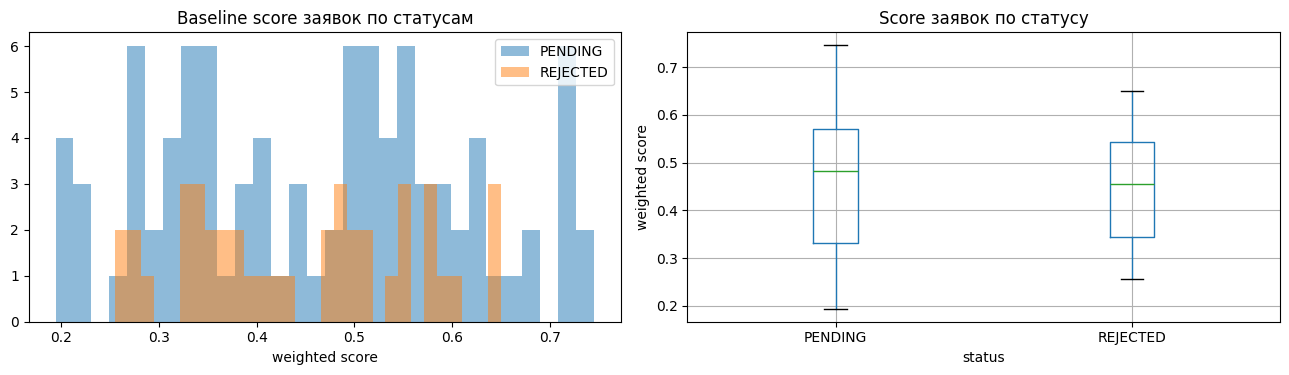

Note: статусы синтетические, поэтому сильного разделения APPROVED/REJECTED ждать не нужно.


In [12]:
app_score_rows = []
for a in applications:
    cached = rank_cache.get(a.student_id)
    if not cached or a.project_id not in cached['weighted_scores']:
        continue
    signals = cached['signals']
    payload = {
        'application_id': a.id,
        'student_id': a.student_id,
        'project_id': a.project_id,
        'status': a.status,
        'tag': signals['tag'].get(a.project_id, 0.0),
        'collab': signals['collab'].get(a.project_id, 0.0),
        'semantic': signals['semantic'].get(a.project_id, 0.0),
        'grades': signals['grades'].get(a.project_id, 0.0),
        'score': cached['weighted_scores'][a.project_id],
    }
    app_score_rows.append(payload)

app_score_df = pd.DataFrame(app_score_rows)
display(app_score_df.groupby('status')[['score', 'tag', 'collab', 'semantic', 'grades']].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for status, group in app_score_df.groupby('status'):
    axes[0].hist(group['score'], bins=30, alpha=0.5, label=status)
axes[0].set_title('Baseline score заявок по статусам')
axes[0].set_xlabel('weighted score')
axes[0].legend()

app_score_df.boxplot(column='score', by='status', ax=axes[1])
axes[1].set_title('Score заявок по статусу')
axes[1].set_xlabel('status')
axes[1].set_ylabel('weighted score')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Note: статусы синтетические, поэтому сильного разделения APPROVED/REJECTED ждать не нужно.')

,capacity,approved,pending,rejected,applications,fill_rate,demand_pressure
count,200.0,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,3.0,0.800000,0.465000,0.210000,1.475000,0.266667,0.491667
std,0.0,1.307112,0.901576,0.432243,2.140628,0.435704,0.713543
min,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.333333
75%,3.0,1.000000,1.000000,0.000000,2.000000,0.333333,0.666667
max,3.0,8.000000,4.000000,2.000000,11.000000,2.666667,3.666667


,metric,value
0,projects_with_applications,102.000000
1,projects_with_approved,82.000000
2,projects_over_capacity,8.000000
3,mean_fill_rate,0.266667
4,median_fill_rate,0.000000
5,mean_demand_pressure,0.491667


,project_id,title,capacity,applications,approved,fill_rate,demand_pressure
172,173,Платформа для аналитики финансовых результатов компаний,3,11,8,2.666667,3.666667
182,183,Система контроля качества для e-commerce на основе кросс-доменной адаптации методов обнаружения фейков с использован...,3,10,5,1.666667,3.333333
185,186,Разработка стратегии выхода 5Post на рынок экспресс-доставки в РФ на основе конкурентного и рыночного анализа,3,10,7,2.333333,3.333333
61,62,Разработка прототипа 2D игры платформера,3,9,5,1.666667,3.000000
179,180,Разработка интеллектуальной системы управления игровым процессом и достижениями в Steam,3,8,6,2.000000,2.666667
156,157,Разработка и анализ новых инструментов промпт-инжиниринга с использованием методов Design-мышления,3,7,3,1.000000,2.333333
101,102,Разработка социальной сети с рекомендательной системой постов на основе методов машинного обучения,3,6,2,0.666667,2.000000
188,189,Разработка телеграмм бота для фитнеса (от партнеров Т- банк),3,6,2,0.666667,2.000000
132,133,Маркетинговая стратегия компании,3,6,4,1.333333,2.000000
180,181,Взаимосвязь практик эмоционального потребления и финансового поведения студенческой молодежи московских вузов,3,6,2,0.666667,2.000000


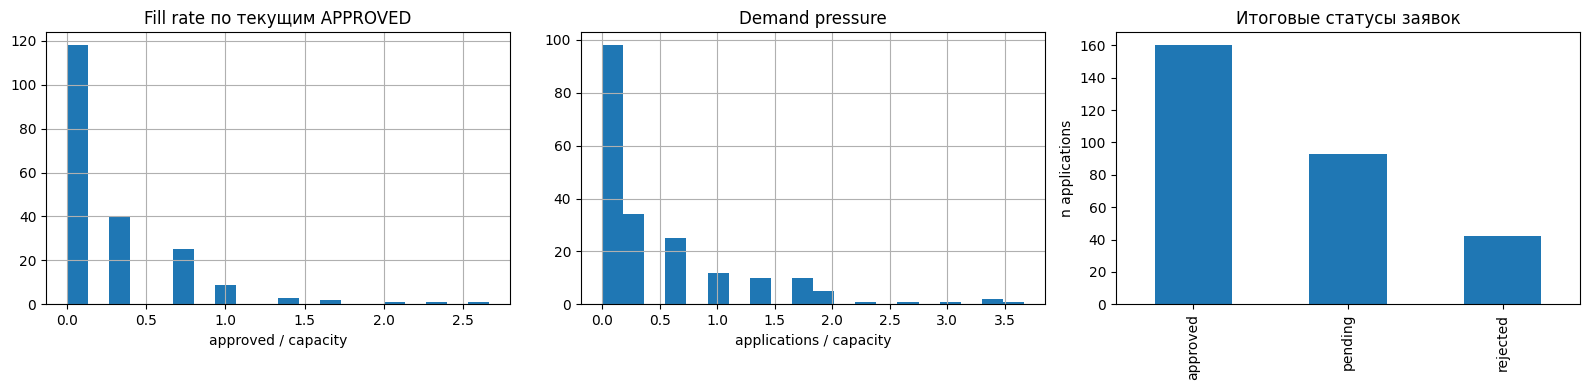

In [13]:
outcome_rows = []
for p in projects:
    apps_for_project = [a for a in applications if a.project_id == p.id]
    approved = sum(a.status == Application.Status.APPROVED for a in apps_for_project)
    pending = sum(a.status == Application.Status.PENDING for a in apps_for_project)
    rejected = sum(a.status == Application.Status.REJECTED for a in apps_for_project)
    outcome_rows.append({
        'project_id': p.id,
        'title': p.title,
        'capacity': p.max_participants,
        'approved': approved,
        'pending': pending,
        'rejected': rejected,
        'participants': p.participants.count(),
        'applications': len(apps_for_project),
        'fill_rate': approved / p.max_participants if p.max_participants else np.nan,
        'over_capacity': approved > p.max_participants,
        'demand_pressure': len(apps_for_project) / p.max_participants if p.max_participants else np.nan,
    })

outcome_df = pd.DataFrame(outcome_rows)
display(outcome_df[['capacity', 'approved', 'pending', 'rejected', 'applications', 'fill_rate', 'demand_pressure']].describe())

baseline_outcome_summary = pd.DataFrame([
    {'metric': 'projects_with_applications', 'value': int((outcome_df['applications'] > 0).sum())},
    {'metric': 'projects_with_approved', 'value': int((outcome_df['approved'] > 0).sum())},
    {'metric': 'projects_over_capacity', 'value': int(outcome_df['over_capacity'].sum())},
    {'metric': 'mean_fill_rate', 'value': float(outcome_df['fill_rate'].mean())},
    {'metric': 'median_fill_rate', 'value': float(outcome_df['fill_rate'].median())},
    {'metric': 'mean_demand_pressure', 'value': float(outcome_df['demand_pressure'].mean())},
])
display(baseline_outcome_summary)

display(outcome_df.sort_values('demand_pressure', ascending=False).head(10)[['project_id', 'title', 'capacity', 'applications', 'approved', 'fill_rate', 'demand_pressure']])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
outcome_df['fill_rate'].hist(ax=axes[0], bins=20)
axes[0].set_title('Fill rate по текущим APPROVED')
axes[0].set_xlabel('approved / capacity')

outcome_df['demand_pressure'].hist(ax=axes[1], bins=20)
axes[1].set_title('Demand pressure')
axes[1].set_xlabel('applications / capacity')

outcome_df[['approved', 'pending', 'rejected']].sum().plot(kind='bar', ax=axes[2])
axes[2].set_title('Итоговые статусы заявок')
axes[2].set_ylabel('n applications')
plt.tight_layout()
plt.show()

In [14]:
# Компактная таблица baseline-метрик, которую потом можно сохранить и сравнить с другими сценариями.
baseline_metrics = {
    'n_projects': len(projects),
    'n_students': len(students),
    'n_applications': len(applications),
    'hit_at_1': float(rank_df['hit_at_1'].mean()),
    'hit_at_3': float(rank_df['hit_at_3'].mean()),
    'hit_at_5': float(rank_df['hit_at_5'].mean()),
    'hit_at_10': float(rank_df['hit_at_10'].mean()),
    'hit_at_20': float(rank_df['hit_at_20'].mean()),
    'median_rank_if_found': float(rank_df.loc[rank_df['rank'].notna(), 'rank'].median()),
    'mean_fill_rate_random_statuses': float(outcome_df['fill_rate'].mean()),
    'projects_over_capacity_random_statuses': int(outcome_df['over_capacity'].sum()),
    'mean_demand_pressure': float(outcome_df['demand_pressure'].mean()),
}

baseline_metrics_df = pd.DataFrame([baseline_metrics]).T.rename(columns={0: 'value'})
display(baseline_metrics_df)

# При необходимости можно раскомментировать:
# baseline_metrics_df.to_csv(ROOT / 'generate_data' / 'baseline_recommendation_metrics.csv')

,value
n_projects,200.000000
n_students,150.000000
n_applications,295.000000
hit_at_1,0.027119
hit_at_3,0.111864
hit_at_5,0.186441
hit_at_10,0.237288
hit_at_20,0.335593
median_rank_if_found,9.000000
mean_fill_rate_random_statuses,0.266667


## Что добавить дальше для сравнения сценариев

Когда появится полноценный Gale-Shapley или project-side ranking, этот notebook можно расширить не переписывая baseline:

- `scenario`-таблица: `baseline_random_status`, `gale_shapley`, `project_side_ranking`, `new_weights_vX`.
- Сравнение `fill_rate`, `over_capacity`, `unmatched_students`, `matched_students`, `mean_rank_of_match`.
- Доля студентов, получивших проект из top-1/top-3/top-5 своей выдачи.
- Доля проектов, получивших студентов из top-1/top-3/top-5 project-side ranking.
- Stability diagnostics для Gale-Shapley: число blocking pairs или хотя бы приближение через взаимные предпочтения.
- Fairness-графики: распределение матчей по программе, курсу, кампусу, уровню образования.
- Capacity pressure до и после matching: какие проекты остаются перегретыми, а какие недозаполнены.
- Sankey/heatmap переходов: куда ушли заявки относительно рекомендаций и итогового распределения.

Главная идея: текущий notebook фиксирует baseline-срез. Потом новые сценарии должны производить таблицу того же формата, чтобы графики сравнения строились автоматически.